In [2]:
import pandas as pd

In [3]:
d=pd.read_csv("pbl.csv")

In [4]:
d

,userId,movieId,rating,timestamp,movie_title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
...,...,...,...,...,...,...
100245,610,166534,4.0,1493848402,Split (2017),Drama|Horror|Thriller
100246,610,168248,5.0,1493850091,John Wick: Chapter Two (2017),Action|Crime|Thriller
100247,610,168250,5.0,1494273047,Get Out (2017),Horror
100248,610,168252,5.0,1493846352,Logan (2017),Action|Sci-Fi


In [5]:
df=pd.DataFrame(d)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100250 entries, 0 to 100249
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   userId       100250 non-null  int64  
 1   movieId      100250 non-null  int64  
 2   rating       100250 non-null  float64
 3   timestamp    100250 non-null  int64  
 4   movie_title  100250 non-null  str    
 5   genres       100250 non-null  str    
dtypes: float64(1), int64(3), str(2)
memory usage: 8.8 MB


In [7]:
df.columns


Index(['userId', 'movieId', 'rating', 'timestamp', 'movie_title', 'genres'], dtype='str')

In [8]:
df.describe()

,userId,movieId,rating,timestamp
count,100250.000000,100250.000000,100250.000000,1.002500e+05
mean,325.973566,19122.092489,3.501606,1.204787e+09
std,182.520792,35260.139972,1.041904,2.161079e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1198.000000,3.000000,1.014822e+09
50%,325.000000,2973.000000,3.500000,1.182911e+09
75%,477.000000,7458.000000,4.000000,1.435944e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [9]:
df.isnull().sum()

userId         0
movieId        0
rating         0
timestamp      0
movie_title    0
genres         0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.size

601500

In [12]:
df.shape

(100250, 6)

In [13]:

df = df.drop('timestamp', axis=1)

In [14]:
df['genres'] = df['genres'].apply(lambda x: x.split('|'))

In [15]:


from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(df['genres']),
    columns=mlb.classes_,
    index=df.index
)

In [16]:
df = pd.concat([df, genre_encoded], axis=1)
df.drop('genres', axis=1, inplace=True)

In [17]:
df

,userId,movieId,rating,movie_title,(no genres listed),Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,1,4.0,Toy Story (1995),0,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,3,4.0,Grumpier Old Men (1995),0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
2,1,6,4.0,Heat (1995),0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
4,1,50,5.0,"Usual Suspects, The (1995)",0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100245,610,166534,4.0,Split (2017),0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
100246,610,168248,5.0,John Wick: Chapter Two (2017),0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
100247,610,168250,5.0,Get Out (2017),0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
100248,610,168252,5.0,Logan (2017),0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [18]:


!pip install sentence-transformers

In [46]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(
    df['movie_title'].tolist(),
    batch_size=64,
    show_progress_bar=True
)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1567 [00:00<?, ?it/s]

In [47]:
embeddings

array([[-0.08283507,  0.05303043,  0.0535765 , ...,  0.02261554,
         0.05381414,  0.10296968],
       [-0.09878676,  0.01764993, -0.05274411, ..., -0.01200616,
         0.03025525,  0.00041654],
       [-0.12817231,  0.06685322, -0.02763729, ...,  0.033102  ,
        -0.0337333 ,  0.02931435],
       ...,
       [ 0.00563253,  0.08499017, -0.00670312, ..., -0.00521667,
        -0.04864561,  0.0572192 ],
       [-0.08247557, -0.03806424, -0.02663678, ..., -0.04784022,
         0.00362067, -0.02790939],
       [-0.11340491,  0.03605567, -0.05413796, ..., -0.08671237,
        -0.02378509,  0.02397779]], shape=(100250, 384), dtype=float32)

In [48]:
df

,userId,movieId,rating,movie_title,(no genres listed),Action,Adventure,Animation,Children,Comedy,...,Thriller,War,Western,embedding,movie_rating_count,user_rating_count,movie_avg_rating,preference,userId_encoded,movieId_encoded
0,1,1,4.0,Toy Story (1995),0,0,1,1,1,1,...,0,0,0,"[-0.08283507078886032, 0.053030434995889664, 0...",0.652439,0.079401,0.760207,1,0,0
1,1,3,4.0,Grumpier Old Men (1995),0,0,0,0,0,1,...,0,0,0,"[-0.09878675639629364, 0.017649933695793152, -...",0.155488,0.079401,0.613248,1,0,2
2,1,6,4.0,Heat (1995),0,1,0,0,0,0,...,1,0,0,"[-0.12817230820655823, 0.06685321778059006, -0...",0.307927,0.079401,0.765795,1,0,5
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),0,0,0,0,0,0,...,1,0,0,"[-0.10050845891237259, -0.004140883218497038, ...",0.615854,0.079401,0.772304,1,0,43
4,1,50,5.0,"Usual Suspects, The (1995)",0,0,0,0,0,0,...,1,0,0,"[-0.07549017667770386, 0.030513938516378403, -...",0.618902,0.079401,0.830610,1,0,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100245,610,166534,4.0,Split (2017),0,0,0,0,0,0,...,1,0,0,"[-0.07886586338281631, -0.007343222852796316, ...",0.015244,0.470787,0.629630,1,609,9133
100246,610,168248,5.0,John Wick: Chapter Two (2017),0,1,0,0,0,0,...,1,0,0,"[-0.09695696085691452, 0.025362255051732063, 0...",0.018293,0.470787,0.809524,1,609,9160
100247,610,168250,5.0,Get Out (2017),0,0,0,0,0,0,...,0,0,0,"[0.005632532294839621, 0.08499017357826233, -0...",0.042683,0.470787,0.696296,1,609,9161
100248,610,168252,5.0,Logan (2017),0,1,0,0,0,0,...,0,0,0,"[-0.08247557282447815, -0.03806424140930176, -...",0.073171,0.470787,0.840000,1,609,9162


In [49]:
df['embedding'] = embeddings.tolist()

In [50]:
import numpy as np

X_embed = np.vstack(df['embedding'].values)

In [51]:
import pandas as pd

embedding_df = pd.DataFrame(X_embed)


In [52]:
df

,userId,movieId,rating,movie_title,(no genres listed),Action,Adventure,Animation,Children,Comedy,...,Thriller,War,Western,embedding,movie_rating_count,user_rating_count,movie_avg_rating,preference,userId_encoded,movieId_encoded
0,1,1,4.0,Toy Story (1995),0,0,1,1,1,1,...,0,0,0,"[-0.08283507078886032, 0.053030434995889664, 0...",0.652439,0.079401,0.760207,1,0,0
1,1,3,4.0,Grumpier Old Men (1995),0,0,0,0,0,1,...,0,0,0,"[-0.09878675639629364, 0.017649933695793152, -...",0.155488,0.079401,0.613248,1,0,2
2,1,6,4.0,Heat (1995),0,1,0,0,0,0,...,1,0,0,"[-0.12817230820655823, 0.06685321778059006, -0...",0.307927,0.079401,0.765795,1,0,5
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),0,0,0,0,0,0,...,1,0,0,"[-0.10050845891237259, -0.004140883218497038, ...",0.615854,0.079401,0.772304,1,0,43
4,1,50,5.0,"Usual Suspects, The (1995)",0,0,0,0,0,0,...,1,0,0,"[-0.07549017667770386, 0.030513938516378403, -...",0.618902,0.079401,0.830610,1,0,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100245,610,166534,4.0,Split (2017),0,0,0,0,0,0,...,1,0,0,"[-0.07886586338281631, -0.007343222852796316, ...",0.015244,0.470787,0.629630,1,609,9133
100246,610,168248,5.0,John Wick: Chapter Two (2017),0,1,0,0,0,0,...,1,0,0,"[-0.09695696085691452, 0.025362255051732063, 0...",0.018293,0.470787,0.809524,1,609,9160
100247,610,168250,5.0,Get Out (2017),0,0,0,0,0,0,...,0,0,0,"[0.005632532294839621, 0.08499017357826233, -0...",0.042683,0.470787,0.696296,1,609,9161
100248,610,168252,5.0,Logan (2017),0,1,0,0,0,0,...,0,0,0,"[-0.08247557282447815, -0.03806424140930176, -...",0.073171,0.470787,0.840000,1,609,9162


In [53]:
movie_popularity = df.groupby("movieId")["rating"].count()

df["movie_rating_count"] = df["movieId"].map(movie_popularity)

In [54]:
user_activity = df.groupby("userId")["rating"].count()
df["user_rating_count"] = df["userId"].map(user_activity)

In [55]:
df

,userId,movieId,rating,movie_title,(no genres listed),Action,Adventure,Animation,Children,Comedy,...,Thriller,War,Western,embedding,movie_rating_count,user_rating_count,movie_avg_rating,preference,userId_encoded,movieId_encoded
0,1,1,4.0,Toy Story (1995),0,0,1,1,1,1,...,0,0,0,"[-0.08283507078886032, 0.053030434995889664, 0...",215,232,0.760207,1,0,0
1,1,3,4.0,Grumpier Old Men (1995),0,0,0,0,0,1,...,0,0,0,"[-0.09878675639629364, 0.017649933695793152, -...",52,232,0.613248,1,0,2
2,1,6,4.0,Heat (1995),0,1,0,0,0,0,...,1,0,0,"[-0.12817230820655823, 0.06685321778059006, -0...",102,232,0.765795,1,0,5
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),0,0,0,0,0,0,...,1,0,0,"[-0.10050845891237259, -0.004140883218497038, ...",203,232,0.772304,1,0,43
4,1,50,5.0,"Usual Suspects, The (1995)",0,0,0,0,0,0,...,1,0,0,"[-0.07549017667770386, 0.030513938516378403, -...",204,232,0.830610,1,0,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100245,610,166534,4.0,Split (2017),0,0,0,0,0,0,...,1,0,0,"[-0.07886586338281631, -0.007343222852796316, ...",6,1277,0.629630,1,609,9133
100246,610,168248,5.0,John Wick: Chapter Two (2017),0,1,0,0,0,0,...,1,0,0,"[-0.09695696085691452, 0.025362255051732063, 0...",7,1277,0.809524,1,609,9160
100247,610,168250,5.0,Get Out (2017),0,0,0,0,0,0,...,0,0,0,"[0.005632532294839621, 0.08499017357826233, -0...",15,1277,0.696296,1,609,9161
100248,610,168252,5.0,Logan (2017),0,1,0,0,0,0,...,0,0,0,"[-0.08247557282447815, -0.03806424140930176, -...",25,1277,0.840000,1,609,9162


In [56]:

movie_avg = df.groupby("movieId")["rating"].mean()
df["movie_avg_rating"] = df["movieId"].map(movie_avg)

In [57]:
df

,userId,movieId,rating,movie_title,(no genres listed),Action,Adventure,Animation,Children,Comedy,...,Thriller,War,Western,embedding,movie_rating_count,user_rating_count,movie_avg_rating,preference,userId_encoded,movieId_encoded
0,1,1,4.0,Toy Story (1995),0,0,1,1,1,1,...,0,0,0,"[-0.08283507078886032, 0.053030434995889664, 0...",215,232,3.920930,1,0,0
1,1,3,4.0,Grumpier Old Men (1995),0,0,0,0,0,1,...,0,0,0,"[-0.09878675639629364, 0.017649933695793152, -...",52,232,3.259615,1,0,2
2,1,6,4.0,Heat (1995),0,1,0,0,0,0,...,1,0,0,"[-0.12817230820655823, 0.06685321778059006, -0...",102,232,3.946078,1,0,5
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),0,0,0,0,0,0,...,1,0,0,"[-0.10050845891237259, -0.004140883218497038, ...",203,232,3.975369,1,0,43
4,1,50,5.0,"Usual Suspects, The (1995)",0,0,0,0,0,0,...,1,0,0,"[-0.07549017667770386, 0.030513938516378403, -...",204,232,4.237745,1,0,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100245,610,166534,4.0,Split (2017),0,0,0,0,0,0,...,1,0,0,"[-0.07886586338281631, -0.007343222852796316, ...",6,1277,3.333333,1,609,9133
100246,610,168248,5.0,John Wick: Chapter Two (2017),0,1,0,0,0,0,...,1,0,0,"[-0.09695696085691452, 0.025362255051732063, 0...",7,1277,4.142857,1,609,9160
100247,610,168250,5.0,Get Out (2017),0,0,0,0,0,0,...,0,0,0,"[0.005632532294839621, 0.08499017357826233, -0...",15,1277,3.633333,1,609,9161
100248,610,168252,5.0,Logan (2017),0,1,0,0,0,0,...,0,0,0,"[-0.08247557282447815, -0.03806424140930176, -...",25,1277,4.280000,1,609,9162


In [58]:
import numpy as np

In [59]:
df["preference"] = np.where(df["rating"] >= 3, 1, 0)

In [60]:


df

,userId,movieId,rating,movie_title,(no genres listed),Action,Adventure,Animation,Children,Comedy,...,Thriller,War,Western,embedding,movie_rating_count,user_rating_count,movie_avg_rating,preference,userId_encoded,movieId_encoded
0,1,1,4.0,Toy Story (1995),0,0,1,1,1,1,...,0,0,0,"[-0.08283507078886032, 0.053030434995889664, 0...",215,232,3.920930,1,0,0
1,1,3,4.0,Grumpier Old Men (1995),0,0,0,0,0,1,...,0,0,0,"[-0.09878675639629364, 0.017649933695793152, -...",52,232,3.259615,1,0,2
2,1,6,4.0,Heat (1995),0,1,0,0,0,0,...,1,0,0,"[-0.12817230820655823, 0.06685321778059006, -0...",102,232,3.946078,1,0,5
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),0,0,0,0,0,0,...,1,0,0,"[-0.10050845891237259, -0.004140883218497038, ...",203,232,3.975369,1,0,43
4,1,50,5.0,"Usual Suspects, The (1995)",0,0,0,0,0,0,...,1,0,0,"[-0.07549017667770386, 0.030513938516378403, -...",204,232,4.237745,1,0,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100245,610,166534,4.0,Split (2017),0,0,0,0,0,0,...,1,0,0,"[-0.07886586338281631, -0.007343222852796316, ...",6,1277,3.333333,1,609,9133
100246,610,168248,5.0,John Wick: Chapter Two (2017),0,1,0,0,0,0,...,1,0,0,"[-0.09695696085691452, 0.025362255051732063, 0...",7,1277,4.142857,1,609,9160
100247,610,168250,5.0,Get Out (2017),0,0,0,0,0,0,...,0,0,0,"[0.005632532294839621, 0.08499017357826233, -0...",15,1277,3.633333,1,609,9161
100248,610,168252,5.0,Logan (2017),0,1,0,0,0,0,...,0,0,0,"[-0.08247557282447815, -0.03806424140930176, -...",25,1277,4.280000,1,609,9162


In [61]:
pip install scikit-learn

In [62]:
from sklearn.preprocessing import MinMaxScaler

In [63]:
scaler = MinMaxScaler()

cols_to_scale = [ "movie_rating_count", 
                 "user_rating_count", "movie_avg_rating"]

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [64]:
df["userId_encoded"] = df["userId"].astype("category").cat.codes
df["movieId_encoded"] = df["movieId"].astype("category").cat.codes

In [65]:
df

,userId,movieId,rating,movie_title,(no genres listed),Action,Adventure,Animation,Children,Comedy,...,Thriller,War,Western,embedding,movie_rating_count,user_rating_count,movie_avg_rating,preference,userId_encoded,movieId_encoded
0,1,1,4.0,Toy Story (1995),0,0,1,1,1,1,...,0,0,0,"[-0.08283507078886032, 0.053030434995889664, 0...",0.652439,0.079401,0.760207,1,0,0
1,1,3,4.0,Grumpier Old Men (1995),0,0,0,0,0,1,...,0,0,0,"[-0.09878675639629364, 0.017649933695793152, -...",0.155488,0.079401,0.613248,1,0,2
2,1,6,4.0,Heat (1995),0,1,0,0,0,0,...,1,0,0,"[-0.12817230820655823, 0.06685321778059006, -0...",0.307927,0.079401,0.765795,1,0,5
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),0,0,0,0,0,0,...,1,0,0,"[-0.10050845891237259, -0.004140883218497038, ...",0.615854,0.079401,0.772304,1,0,43
4,1,50,5.0,"Usual Suspects, The (1995)",0,0,0,0,0,0,...,1,0,0,"[-0.07549017667770386, 0.030513938516378403, -...",0.618902,0.079401,0.830610,1,0,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100245,610,166534,4.0,Split (2017),0,0,0,0,0,0,...,1,0,0,"[-0.07886586338281631, -0.007343222852796316, ...",0.015244,0.470787,0.629630,1,609,9133
100246,610,168248,5.0,John Wick: Chapter Two (2017),0,1,0,0,0,0,...,1,0,0,"[-0.09695696085691452, 0.025362255051732063, 0...",0.018293,0.470787,0.809524,1,609,9160
100247,610,168250,5.0,Get Out (2017),0,0,0,0,0,0,...,0,0,0,"[0.005632532294839621, 0.08499017357826233, -0...",0.042683,0.470787,0.696296,1,609,9161
100248,610,168252,5.0,Logan (2017),0,1,0,0,0,0,...,0,0,0,"[-0.08247557282447815, -0.03806424140930176, -...",0.073171,0.470787,0.840000,1,609,9162


In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector

In [67]:


X = df.drop(columns=['preference', 'movie_title', 'timestamp','rating','userId','movieId','embedding'], errors='ignore')
y = df['preference']

In [68]:
model = LogisticRegression(max_iter=1000)


In [69]:
X.shape


(100250, 25)

In [70]:
sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=12,
    direction='forward',
    cv=3   
)

In [71]:
sfs.fit(X, y)

,estimator estimator: estimator instanceAn unfitted estimator.,LogisticRegre...max_iter=1000)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",12
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mi

In [72]:
selected_features = X.columns[sfs.get_support()]

print(selected_features)

Index(['(no genres listed)', 'Animation', 'Crime', 'Film-Noir', 'Musical',
       'Mystery', 'Romance', 'Thriller', 'War', 'Western', 'user_rating_count',
       'movie_avg_rating'],
      dtype='str')


In [73]:
features = df[[
    '(no genres listed)', 'Animation', 'Crime', 'Film-Noir', 'Musical',
    'Mystery', 'Romance', 'Thriller', 'War', 'Western',
    'user_rating_count', 'movie_avg_rating'
]].values

In [74]:
X_final = np.concatenate([features, embedding_df], axis=1)

In [75]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [76]:
X = X_final
y = df['preference']

In [77]:
X, y

(array([[ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00, ...,
          2.26155352e-02,  5.38141355e-02,  1.02969684e-01],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -1.20061645e-02,  3.02552525e-02,  4.16539784e-04],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00, ...,
          3.31019983e-02, -3.37332971e-02,  2.93143522e-02],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -5.21667162e-03, -4.86456081e-02,  5.72191961e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -4.78402190e-02,  3.62066878e-03, -2.79093869e-02],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00, ...,
         -8.67123678e-02, -2.37850863e-02,  2.39777919e-02]],
       shape=(100250, 396)),
 0         1
 1         1
 2         1
 3         1
 4         1
          ..
 100245    1
 100246    1
 100247    1
 100248    1
 100249    1
 Name: preference, Length: 100250, dtype: int64)

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 36)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append(acc)
    
    print(f"K = {k} , Accuracy = {acc:.3f}")

K = 1 , Accuracy = 0.747
K = 2 , Accuracy = 0.685
K = 3 , Accuracy = 0.794
K = 4 , Accuracy = 0.772
K = 5 , Accuracy = 0.808
K = 6 , Accuracy = 0.796
K = 7 , Accuracy = 0.814
K = 8 , Accuracy = 0.808
K = 9 , Accuracy = 0.817
K = 10 , Accuracy = 0.814
K = 11 , Accuracy = 0.819
K = 12 , Accuracy = 0.816
K = 13 , Accuracy = 0.821
K = 14 , Accuracy = 0.820
K = 15 , Accuracy = 0.823
K = 16 , Accuracy = 0.822
K = 17 , Accuracy = 0.823
K = 18 , Accuracy = 0.823
K = 19 , Accuracy = 0.824
K = 20 , Accuracy = 0.824
K = 21 , Accuracy = 0.824
K = 22 , Accuracy = 0.824
K = 23 , Accuracy = 0.823
K = 24 , Accuracy = 0.824
K = 25 , Accuracy = 0.824
K = 26 , Accuracy = 0.825
K = 27 , Accuracy = 0.824
K = 28 , Accuracy = 0.824
K = 29 , Accuracy = 0.823
K = 30 , Accuracy = 0.824
K = 31 , Accuracy = 0.823
K = 32 , Accuracy = 0.824
K = 33 , Accuracy = 0.824
K = 34 , Accuracy = 0.823
K = 35 , Accuracy = 0.824


In [80]:
knn = KNeighborsClassifier(n_neighbors=33)

In [81]:
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",33
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [82]:



y_pred = knn.predict(X_test)


In [83]:
y_test


19212    1
6491     1
94929    1
63679    0
78476    0
        ..
53495    0
64861    1
18416    1
62062    1
43470    1
Name: preference, Length: 20050, dtype: int64

In [84]:
y_pred

array([1, 1, 1, ..., 1, 1, 0], shape=(20050,))

In [85]:
accuracy_score(y_test, y_pred)

0.8235910224438903

In [86]:
precision_score(y_test, y_pred)

0.8274835796387521

In [87]:
recall_score(y_test, y_pred)

0.9892644623029262

In [88]:
f1_score(y_test, y_pred)

0.9011707507893487

In [89]:
print(confusion_matrix(y_test, y_pred))

[[  387  3362]
 [  175 16126]]


In [90]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.10      0.18      3749
           1       0.83      0.99      0.90     16301

    accuracy                           0.82     20050
   macro avg       0.76      0.55      0.54     20050
weighted avg       0.80      0.82      0.77     20050



In [91]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report

In [92]:
X = X_final
y = df["preference"]

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.3, random_state = 42)

In [94]:

from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [95]:
y_pred = logreg.predict(X_test)

In [96]:
y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(30075,))

In [97]:
y_test

19212    1
6491     1
94929    1
63679    0
78476    0
        ..
47962    1
642      1
79195    0
1427     1
30826    0
Name: preference, Length: 30075, dtype: int64

In [98]:

accuracy_score(y_test, y_pred)

0.838669991687448

In [99]:
precision_score(y_test, y_pred)

0.8503028348206286

In [100]:
recall_score(y_test, y_pred)

0.9723371992951109

In [101]:
f1_score(y_test, y_pred)


0.9072346283267054

In [102]:
print(confusion_matrix(y_test, y_pred))

[[ 1497  4177]
 [  675 23726]]


In [103]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.26      0.38      5674
           1       0.85      0.97      0.91     24401

    accuracy                           0.84     30075
   macro avg       0.77      0.62      0.64     30075
weighted avg       0.82      0.84      0.81     30075



In [104]:
from sklearn.svm import LinearSVC

svm = LinearSVC(max_iter=2000)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [105]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

Accuracy: 0.8383042394014962
Precision: 0.8457808296757752
Recall: 0.9792631449530756
F1 Score: 0.9076405902797562


In [106]:

cm = confusion_matrix(y_test, y_pred)
cm

array([[ 1497,  4177],
       [  675, 23726]])

In [107]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.26      0.38      5674
           1       0.85      0.97      0.91     24401

    accuracy                           0.84     30075
   macro avg       0.77      0.62      0.64     30075
weighted avg       0.82      0.84      0.81     30075



In [108]:
from sklearn.ensemble import RandomForestClassifier

In [109]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [110]:
y_pred_rf = rf.predict(X_test)

In [111]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.7579384871155445
Precision: 0.8453067645516518
Recall: 0.8588172615876398
F1 Score: 0.8520084566596194


In [112]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf

array([[ 1839,  3835],
       [ 3445, 20956]])

In [113]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.35      0.32      0.34      5674
           1       0.85      0.86      0.85     24401

    accuracy                           0.76     30075
   macro avg       0.60      0.59      0.59     30075
weighted avg       0.75      0.76      0.75     30075



In [114]:
from sklearn.tree import DecisionTreeClassifier

In [115]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [116]:
y_pred_dt = dt.predict(X_test)

In [117]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_acc)
print("Decision Tree Precision:", dt_precision)
print("Decision Tree Recall:", dt_recall)
print("Decision Tree F1 Score:", dt_f1)

Decision Tree Accuracy: 0.765120532003325
Decision Tree Precision: 0.8575376366261085
Decision Tree Recall: 0.8520552436375558
Decision Tree F1 Score: 0.8547876495498088


In [118]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_dt

array([[ 2220,  3454],
       [ 3610, 20791]])

In [119]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.38      0.39      0.39      5674
           1       0.86      0.85      0.85     24401

    accuracy                           0.77     30075
   macro avg       0.62      0.62      0.62     30075
weighted avg       0.77      0.77      0.77     30075



In [120]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [121]:
# Replace with your trained models
models = {
    'Logistic Regression': logreg,
    'KNN': knn,
    'SVM': svm,
    'Decision Tree': dt,
    'Random Forest': rf
}

In [122]:
results = []

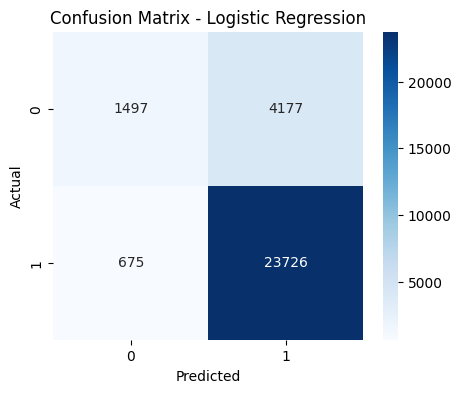

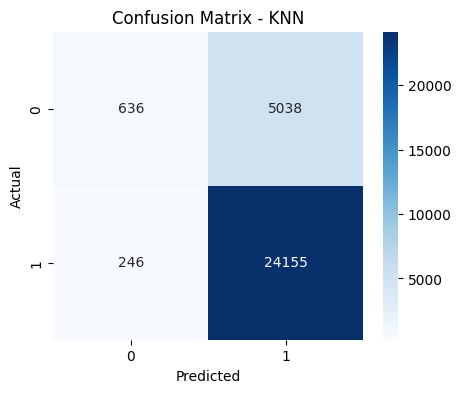

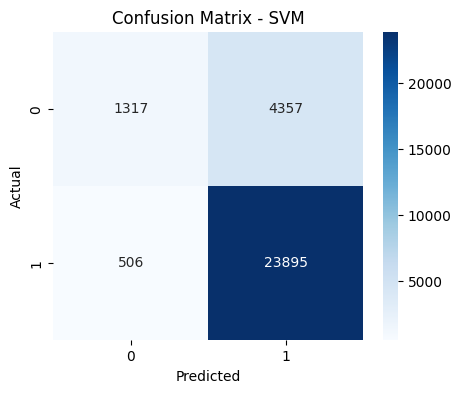

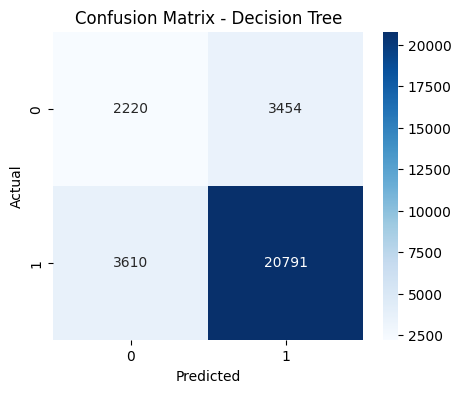

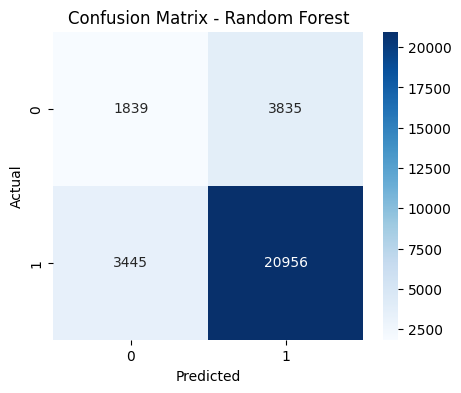

In [123]:
for name, model in models.items():
    # Predictions
    y_pred = model.predict(X_test)
    
    # Probabilities for ROC curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)
    
    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1-Score': f1, 'AUC': auc})
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

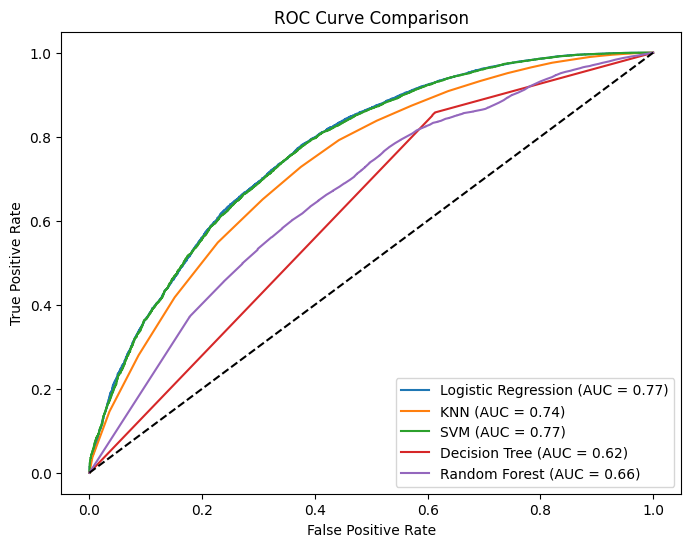

In [124]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

plt.plot([0,1],[0,1],'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [125]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-Score', ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score       AUC
2                  SVM  0.838304   0.845781  0.979263  0.907641  0.769160
0  Logistic Regression  0.838670   0.850303  0.972337  0.907235  0.770722
1                  KNN  0.824306   0.827424  0.989918  0.901407  0.736211
3        Decision Tree  0.765121   0.857538  0.852055  0.854788  0.622101
4        Random Forest  0.757938   0.845307  0.858817  0.852008  0.664023


In [126]:
best_model_name = results_df.sort_values(by='F1-Score', ascending=False)['Model'].iloc[0]
print(f"Best model based on F1-score: {best_model_name}")
best_model = models[best_model_name]

Best model based on F1-score: SVM


In [128]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'C': [0.01, 0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge']
}

random_search = RandomizedSearchCV(
    LinearSVC(max_iter=5000),
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Params: {'loss': 'squared_hinge', 'C': 10}
Best Score: 0.8391877617127325


In [129]:
best_svm = random_search.best_estimator_

In [130]:
svm = SVC()

In [131]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = best_svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8382044887780549
              precision    recall  f1-score   support

           0       0.72      0.23      0.35      5674
           1       0.85      0.98      0.91     24401

    accuracy                           0.84     30075
   macro avg       0.78      0.61      0.63     30075
weighted avg       0.82      0.84      0.80     30075



In [132]:
import joblib
import json
import numpy as np

In [133]:
from sklearn.svm import LinearSVC

svm = LinearSVC(max_iter=2000)
svm.fit(X_train, y_train)

import joblib
joblib.dump(svm, "svm_model.pkl")

['svm_model.pkl']

In [134]:

# 1. Save trained ML model (SVM)
joblib.dump(svm, "svm_model.pkl")


# 3. Save scaler
joblib.dump(scaler, "scaler.pkl")

# 4. Save embedding model name 
embedding_model_name = "all-MiniLM-L6-v2"
joblib.dump(embedding_model_name, "embedding_model.pkl")

['embedding_model.pkl']

In [135]:
from sentence_transformers import SentenceTransformer


# save model reference name (not full model usually needed)
joblib.dump("all-MiniLM-L6-v2", "embedding_model_name.pkl")

['embedding_model_name.pkl']

In [136]:
import json

feature_columns = [
 '(no genres listed)', 'Animation', 'Crime', 'Film-Noir', 'Musical',
 'Mystery', 'Romance', 'Thriller', 'War', 'Western',
 'user_rating_count',
 'movie_avg_rating'
]

# if embeddings exist:
for i in range(384):   # or your embedding size
    feature_columns.append(f"emb_{i}")

with open("feature_columns.json", "w") as f:
    json.dump(feature_columns, f)

In [138]:
scaler = MinMaxScaler()

df[['user_rating_count', 'movie_avg_rating']] = scaler.fit_transform(
    df[['user_rating_count', 'movie_avg_rating']]
)

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']